### This script is used to plot already calculated and retransformed (from box-cox scale to original scale) partial dependence plots:

input files: "../../../output_data/ML_analysis/partial_dependence_plots_paper/pdp_results_original_scale_average.pkl"

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgba
from matplotlib.gridspec import GridSpec
import seaborn as sns
import matplotlib.ticker as mticker
import pickle
import os


In [18]:
# define the output folder path:

output_folder = '../../../figures/pdp_plots'

# Check if the folder exists, if not, create it:
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [19]:
catchment_data = pd.read_csv('../../../output_data/input_ML_learning/median_cnp_export_abs_conc_and_rfr_and_basin_feat.csv').drop(columns='Unnamed: 0')

In [20]:
# Load the partial dependence data:
with open(f"../../../output_data/ML_analysis/partial_dependence_plots_paper/pdp_results_original_scale_average.pkl", "rb") as f:
    pdp_data_average = pickle.load(f)

In [21]:
### Create a dictionary containing target variables units: slp, dor, temperature and hdi were converted, check units, if they are plausible:
feature_var_units = {
    'UP_AREA':'[km$^{2}$]' ,
    'twi90':'[-]', 
    'slp_dg_uav':'[°]',
    'for_pc_use':'[%]',
    'crp_pc_use':'[%]',
    'pst_pc_use':'[%]',
    'ppd_pk_uav':'[people km$^{-2}$]',
    'run_mm_syr':'[mm year$^{-1}$]',
    'inu_pc_umn':'[%]',
    'dor_pc_pva':'[%]',
    'ria_ha_usu_perkm2':'[hectares km$^{-2}$]', 
    'riv_tc_usu_perkm2':'[hectares km$^{-2}$]',
    'ele_mt_uav':'[m a.s.l]',
    'sgr_dk_sav':'[dm km$^{-1}$]',
    'tmp_dc_uyr':'[°C]', 
    'pre_mm_uyr':'[mm year$^{-1}$]',
    'pet_mm_uyr':'[mm year$^{-1}$]',
    'aet_mm_uyr':'[mm year$^{-1}$]',
    'snw_pc_uyr':'[%]',
    'wet_pc_ug2':'[%]',
    'ire_pc_use':'[%]',
    'gla_pc_use':'[%]',
    'prm_pc_use':'[%]',
    'pac_pc_use':'[%]',
    'cly_pc_uav':'[%]',
    'slt_pc_uav':'[%]',
    'snd_pc_uav':'[%]',
    'soc_th_uav':'[tonnes hectare$^{-1}$]',
    'swc_pc_uyr':'[%]',
    'kar_pc_use':'[%]',
    'ero_kh_uav':'[kg hectare$^{-1}$ year$^{-1}$]',
    'gdp_ud_usu':'[US dollers]',
    'hdi_ix_sav':'[-]'
}

In [22]:
feature_var_names = {
    'ppd_pk_uav':'Population density',
    'pet_mm_uyr':'Potential evapotranspiration',
    'wet_pc_ug2':'Wetland extent',
    'swc_pc_uyr':'Soil water content',
    'hdi_ix_sav':'Human development index'
}

In [23]:
pdp_data_average

feature_val  partial_dep
var     feature_name nrand                          
c_imbal hdi_ix_sav   0       802.000000     0.038920
                     0       803.505051     0.038898
                     0       805.010101     0.038864
                     0       806.515152     0.038835
                     0       808.020202     0.038793
...                                 ...          ...
p_imbal wet_pc_ug2   4        69.000000     0.167698
                     4        70.000000     0.167719
                     4        71.000000     0.167719
                     4        75.000000     0.167682
                     4        94.000000     0.167682

[6738 rows x 2 columns]

Create a list of all important catchment controls:

In [24]:
perm_imp_features = ['swc_pc_uyr', 'pet_mm_uyr', 'wet_pc_ug2', 'hdi_ix_sav', 'ppd_pk_uav']

(np.float64(0.25), np.float64(104.75))


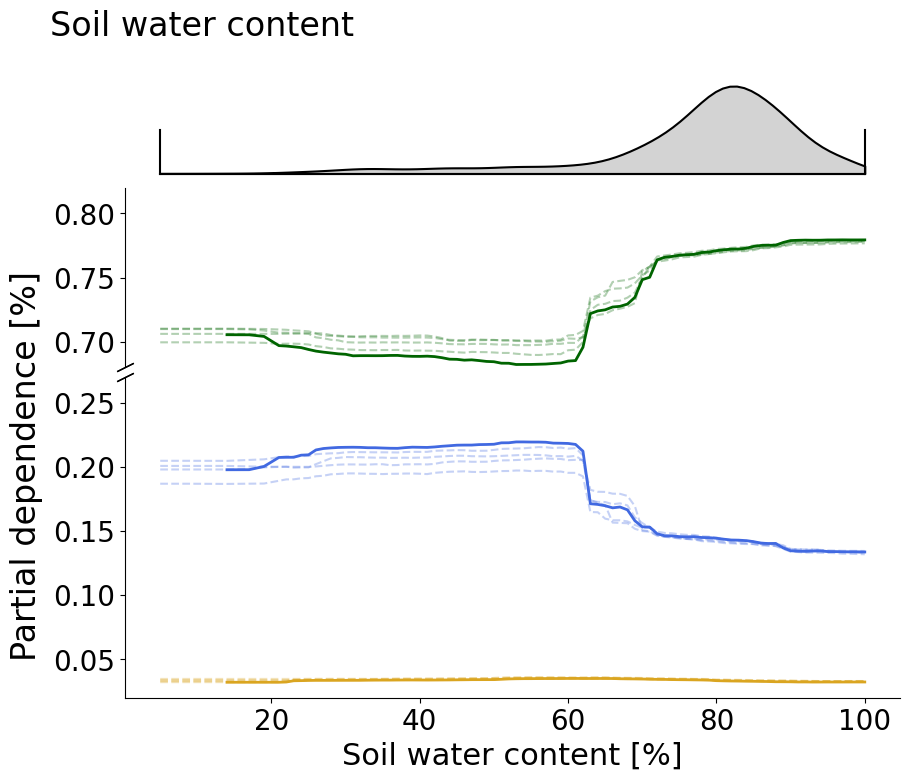

(np.float64(535.1705000000001), np.float64(1482.0395))


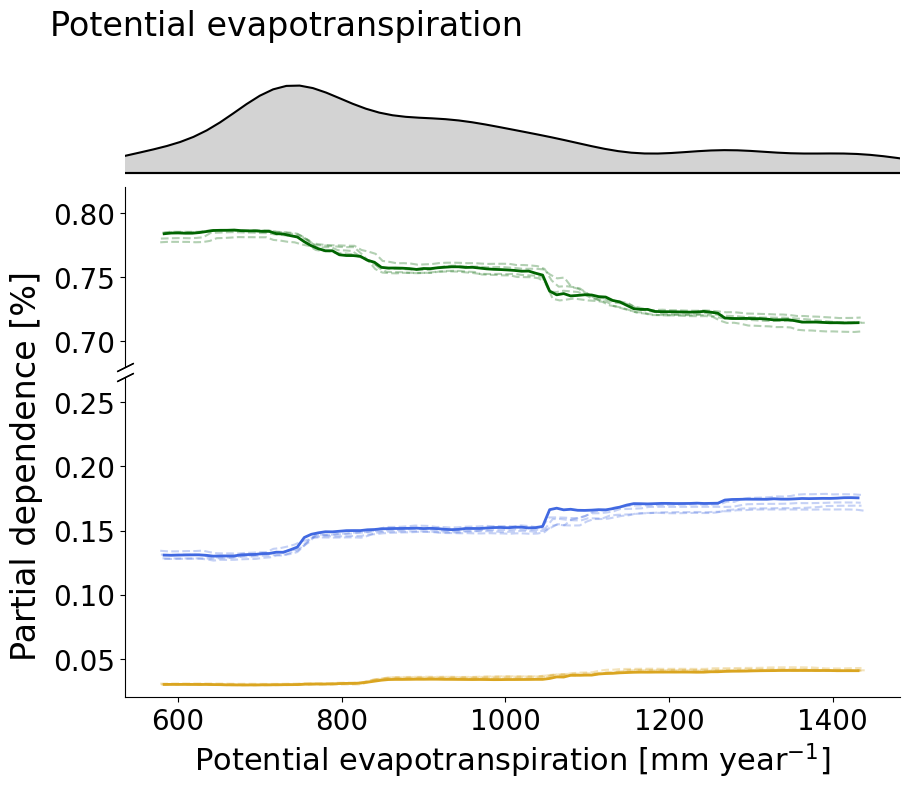

(np.float64(-4.7), np.float64(98.7))


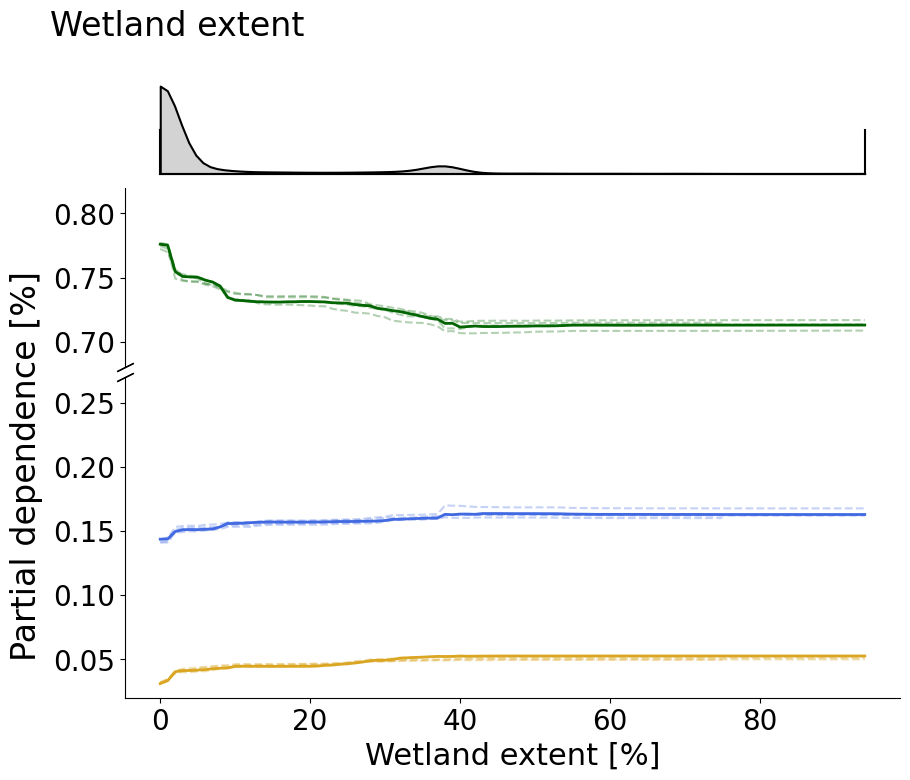

(np.float64(0.7945000000000001), np.float64(0.9594999999999999))


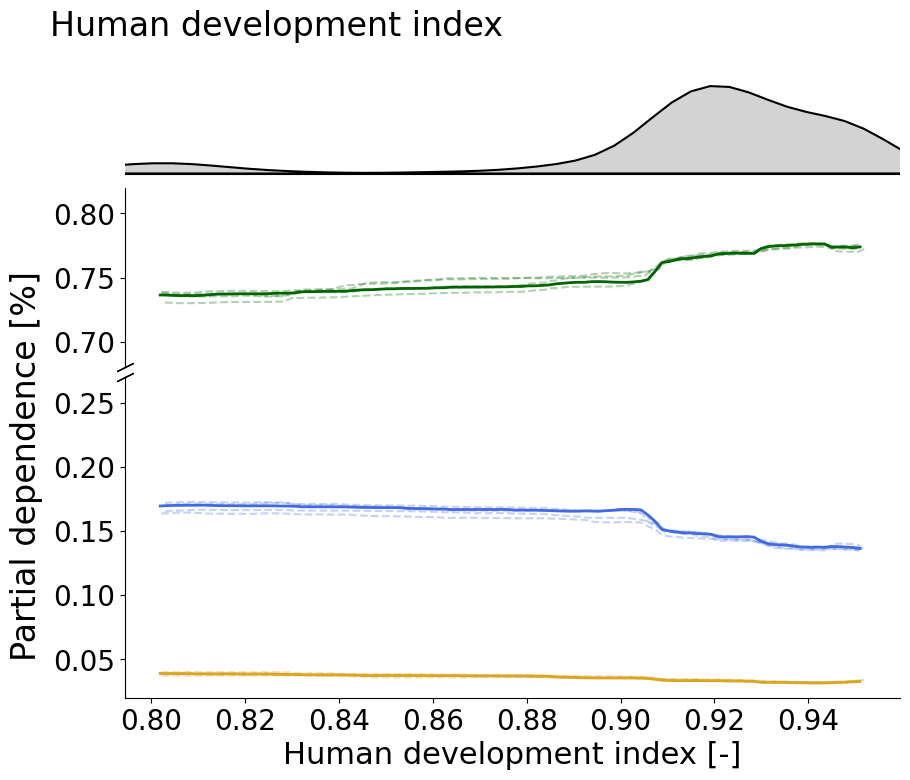

(np.float64(-21.145755), np.float64(506.712015))


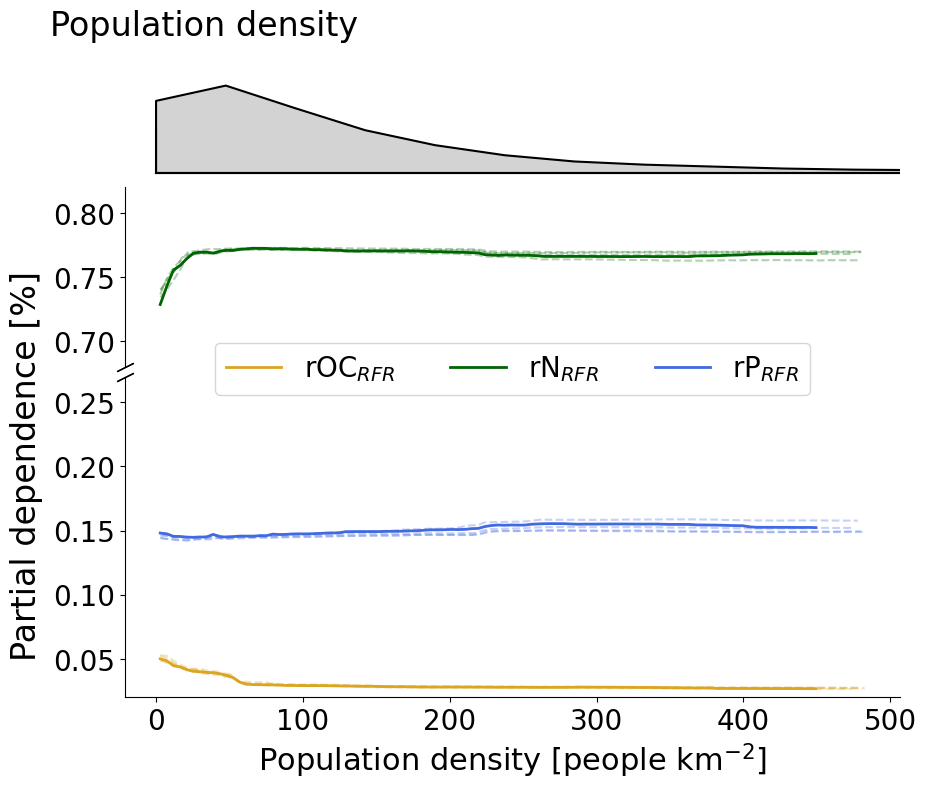

In [25]:


# set number of decimals for axis tick labels
formatter = mticker.FormatStrFormatter('%.2f')  # Adjust decimal places as needed




# List to store figures
fig_list = []

#colors = ['firebrick', 'darkgreen', 'royalblue']
#colors = ['goldenrod', 'darkgreen', 'royalblue']
colors = ['#DAA520', '#006400', '#4169E1']
labels = ['rOC$_{RFR}$', 'rN$_{RFR}$', 'rP$_{RFR}$']
#feature = 'pet_mm_uyr'	

pdp_data_average = pdp_data_average.reset_index().set_index(['feature_name', 'var', 'nrand'])

for feature in perm_imp_features:
    feature_unit = feature_var_units[feature]
    feature_name = feature_var_names[feature]
    data1 = pdp_data_average.loc[feature]
    labeled_targets = set()

    # create a figure with 3 subplots (main plots + marginal histogram)
    #fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
    #fig.subplots_adjust(hspace=0.05) 

    fig = plt.figure(figsize=(10, 8))
    gs = GridSpec(3, 1, height_ratios=[0.3, 0.56, 1], hspace=0.05)
    ax1 = fig.add_subplot(gs[1, 0])
    ax_marginal = fig.add_subplot(gs[0, 0], sharex=ax1)
    ax2 = fig.add_subplot(gs[2, 0], sharex=ax1)
    #ax_marginal = fig.add_subplot(gs[2, 0], sharex=ax1) # marginal violin plot if below the other plots

    if feature == 'hdi_ix_sav':
        catch_dist = catchment_data[feature]/1000
    else:
        catch_dist = catchment_data[feature]

    for i, target in enumerate (data1.index.get_level_values('var').unique()):
        data = data1.loc[target]
        col = colors[i]
        for nrand in data.index.get_level_values('nrand').unique():
            subset = data.loc[nrand]
            label = labels[i] if target not in labeled_targets else None
            if feature == 'hdi_ix_sav':
                if nrand == 0:
                    ax1.plot(subset['feature_val']/1000, subset['partial_dep'], color = col, label = label, linewidth = 2)
                    ax2.plot(subset['feature_val']/1000, subset['partial_dep'], color = col, label = label, linewidth = 2)
                    
                else:
                    ax1.plot(subset['feature_val']/1000, subset['partial_dep'], color = col, label = label, linestyle = 'dashed', alpha = 0.3, linewidth = 1.5)
                    ax2.plot(subset['feature_val']/1000, subset['partial_dep'], color = col, label = label, linestyle = 'dashed', alpha = 0.3, linewidth = 1.5)
            else:
                if nrand == 0:
                    ax1.plot(subset['feature_val'], subset['partial_dep'], color = col, label = label, linewidth = 2)
                    ax2.plot(subset['feature_val'], subset['partial_dep'], color = col, label = label, linewidth = 2)
                    
                else:
                    ax1.plot(subset['feature_val'], subset['partial_dep'], color = col, label = label, linestyle = 'dashed', alpha = 0.3, linewidth = 1.5)
                    ax2.plot(subset['feature_val'], subset['partial_dep'], color = col, label = label, linestyle = 'dashed', alpha = 0.3, linewidth = 1.5)
            labeled_targets.add(target)

    # zoom in or limit the view to different portions of the y-axis:
    ax1.set_ylim(0.68, 0.82)
    ax2.set_ylim(0.02, 0.27)

    # hide axes labels between ax1 and ax2:
    ax1.spines.bottom.set_visible(False)
    ax1.spines.top.set_visible(False)
    ax1.spines.right.set_visible(False)
    ax2.spines.top.set_visible(False)
    ax2.spines.right.set_visible(False)
    ax1.tick_params(axis='x', which='both', length=0) # this removes the major and minor ticks on the x-axis
    ax1.tick_params(labeltop=False, labelbottom = False)  # don't put tick labels at the top
    ax2.xaxis.tick_bottom()
    ax2.tick_params(labeltop=False) # don't put tick labels at the top
    ax1.yaxis.set_major_formatter(formatter)
    ax2.yaxis.set_major_formatter(formatter)
    ax1.set_yticks(np.linspace(0.70, 0.80, num = 3))

   

    d = .5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    ax1.plot([0, 0],[0, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 0],[1, 1], transform=ax2.transAxes, **kwargs)


    ##  Add marginal histogram
    #sns.histplot(catchment_data[feature], ax=ax2, kde=False, color='gray', alpha=0.3)
    # Add marginal histogram or violin plot (independent dataset)
    #sns.histplot(catchment_data[feature], ax=ax_marginal, kde=False, color='gray', alpha=0.3)
    # Or use violinplot instead:
    x_limits = ax1.get_xlim()

    # add a violin plot to the marginal axes:
    #sns.violinplot(x=catch_dist, ax=ax_marginal, linewidth=1, inner = None, color = 'none')
    # or from matplotlib directly:
    vp =ax_marginal.violinplot(catch_dist, vert=False, showmeans=False, showmedians=False, side = 'high')
     # Change facecolor and edgecolor
    for body in vp['bodies']:
        body.set_facecolor(to_rgba('lightgrey'))  # Fill color
        body.set_alpha(1)        # Transparency
        body.set_edgecolor('black') # Border color
        body.set_linewidth(1.5) 
    
    vp['cmins'].set_color('black')
    vp['cmaxes'].set_color('black')
    vp['cbars'].set_color('black')


    # Set the x-axis limits of ax_marginal to match ax1
    ax_marginal.set_xlim(x_limits)
    print(x_limits)

    # Set the axis setting for the marginal plot
    #ax_marginal.set_ylabel("Frequency", fontsize=16)
    #ax_marginal.set_xlabel(f'{feature_name} {feature_unit}', fontsize=22)
    #ax_marginal.tick_params(axis='both', which='major', labelsize=20)
    ax_marginal.spines.top.set_visible(False)
    ax_marginal.spines.right.set_visible(False)
    ax_marginal.spines.bottom.set_visible(False)
    ax_marginal.spines.left.set_visible(False)
    ax_marginal.tick_params(axis='x', which='both', length=0) # this removes the major and minor ticks on the x-axis
    ax_marginal.tick_params(axis='y', which='both', length=0)
    ax_marginal.set_yticklabels([])
    ax_marginal.tick_params(labeltop=False, labelbottom = False)  # don't put tick labels at the top
    ax_marginal.set_xlabel('')
    

    fig.suptitle(f'{feature_name}', fontsize = 24, x = 0.05,  ha = 'left', y = 0.97) # make a title for the whole plot
    fig.text(0.01, 0.4,'Partial dependence [%]', va='center', rotation='vertical', fontsize = 24)
    #fig.suptitle(f'Partial dependence of {feature}', horizontalalignment = 'right', fontsize = 20)
    ax1.tick_params(axis='both', which='major', labelsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=20)
    ax2.set_xlabel(f'{feature_name} {feature_unit}', fontsize=22)
    

    # Add a legend to population density plot: 
    if feature == 'ppd_pk_uav':
        plt.legend(fontsize = 20, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.15))
    #plt.tight_layout()

    # Define the width and height in centimeters
    #width_cm = 15
    #height_cm = 10

    # Convert to inches
    #width_inch = width_cm / 2.54
    #height_inch = height_cm / 2.54

    # Set the figure size
    #fig.set_size_inches(width_inch, height_inch)

    plt.savefig(f'../../../figures/pdp_plots/{feature}_pdp.png', dpi=500, bbox_inches='tight')
    plt.savefig(f'../../../figures/pdp_plots/{feature}_pdp.svg', dpi=500, bbox_inches='tight')
    plt.savefig(f'../../../figures/pdp_plots/{feature}_pdp.pdf', dpi=500, bbox_inches='tight')
    plt.show()
    plt.close(fig)  # Close individual plots to avoid rendering them immediately
    
    # Append to the list
    fig_list.append(fig)


   